# `toxpol.datagen` — Synthetic Data Generation Demo

Polarized Trees needs datasets where the ground truth is *known* — which demographic dimensions drive disagreement, and how strongly. Real annotation data can't provide this, so we generate synthetic datasets with **injected, controlled polarization**.

Each text is independently assigned a **severity tier**:
- **High** — strong, non-overlapping toxic/civil split
- **Moderate** — same mechanism, softer/overlapping split
- **Low** — little to no polarization (mostly a true negative control)

This notebook walks through every public method on `AnnotatorPool`, in order.

**Requires:** `pip install "toxpol-nlp[ndfu]"`

In [1]:
import matplotlib.pyplot as plt

from toxpol.datagen import AnnotatorPool, DEFAULT_DIMENSIONS

## 1. Build the annotator pool

`DEFAULT_DIMENSIONS` covers gender, politics, age, education, and orientation.
Pass a custom dict to use different dimensions or values.
Use `exclude` to drop dimensions for ablation runs.

In [2]:
pool = AnnotatorPool(
    dimensions=DEFAULT_DIMENSIONS,
    exclude=None,                  # drop dimension names, e.g. ["education"]
    annotators_per_identity=10,    # annotators replicated per unique identity
    scale=5,
    toxic_range=(4, 5),             # toxic pole range used by the High tier
    civil_range=(1, 2),             # civil pole range used by the High tier
    neutral_range=(3, 3),           # reserved for future use
)
pool.summary()

Active dimensions : ['gender', 'politics', 'age', 'education', 'orientation']
Unique identities : 162
Annotators/identity: 10
Pool size          : 1620
Rating scale       : 1-5
  toxic_range      : (4, 5)
  civil_range      : (1, 2)
  neutral_range    : (3, 3)


## 2. Generate a dataset

Every text is an **independent draw**: its severity tier, and (for High/Moderate/weighted-Low texts) its own random bias config, are generated fresh per text.

In [3]:
dataset, bias_configs = pool.generate_dataset(
    n_texts=10,
    n_annotators_per_text=100,     # must be <= pool.pool_size (1620)
    noise=0.05,                     # prob. of fully random rating (outlier noise)
    high_ratio=0.60,                # share of texts with strong polarization
    moderate_ratio=0.20,            # share with a softer signal
    low_ratio=0.20,                 # share with little to no polarization
    low_unimodal_share=0.40,        # within Low, fraction with no demographic split
)

print(dataset.head(10))
print("\nTier for each text:")
for text_id, cfg in bias_configs.items():
    print(f"  text {text_id}: {cfg['tier']}" + (f" ({cfg['subcase']})" if cfg.get("subcase") else ""))

   text_id  annotator_id      gender politics    age education   orientation  \
0        0          1578  non-binary    right    >50       low        lgbtq+   
1        0           186        male   center    <25       low  heterosexual   
2        0           823      female   center  25-50      high  heterosexual   
3        0           472        male    right  25-50      high        lgbtq+   
4        0           703      female     left    >50      high  heterosexual   
5        0           111        male     left  25-50      high        lgbtq+   
6        0           278        male   center  25-50    medium        lgbtq+   
7        0           155        male     left    >50    medium        lgbtq+   
8        0          1413  non-binary   center    >50    medium        lgbtq+   
9        0           763      female   center    <25      high  heterosexual   

   rating  
0       1  
1       1  
2       1  
3       4  
4       3  
5       1  
6       2  
7       2  
8       2  

## 3. Inspect each text's bias config

`describe_bias` prints the per-dimension weights (for High/Moderate/weighted-Low texts) or the unimodal peak/spread (for true-unimodal Low texts).

In [4]:
# Show one example of each tier that appears in this dataset
seen = set()
for text_id, cfg in bias_configs.items():
    if cfg["tier"] not in seen:
        seen.add(cfg["tier"])
        pool.describe_bias(bias_configs, text_id=text_id)
        print()

Text 0 -- tier: low (unimodal)
  unimodal peak=1  spread=1.09

Text 1 -- tier: moderate
  threshold (median combined weight): 1.086
  gender       male=1.74  female=0.61  non-binary=1.90
  politics     left=1.70  center=1.12  right=0.51
  age          <25=1.96  25-50=1.12  >50=0.76
  education    low=1.78  medium=0.79  high=1.23
  orientation  heterosexual=0.56  lgbtq+=1.15

Text 2 -- tier: high
  threshold (median combined weight): 1.166
  gender       male=1.03  female=1.53  non-binary=1.37
  politics     left=0.92  center=0.91  right=1.75
  age          <25=0.68  25-50=1.00  >50=1.70
  education    low=1.21  medium=1.45  high=1.67
  orientation  heterosexual=1.09  lgbtq+=0.89



## 4. Per-text nDFU

`summarize` reports the nDFU for one text, broken down by every dimension value.

In [5]:
pool.summarize(dataset, bias_configs, text_id=0)

Text 0 (tier: low) -- overall nDFU: 0.000

gender:
  female: 0.000
  male: 0.000
  non-binary: 0.083

politics:
  center: 0.053
  left: 0.000
  right: 0.087

age:
  25-50: 0.000
  <25: 0.053
  >50: 0.000

education:
  high: 0.056
  low: 0.000
  medium: 0.048

orientation:
  heterosexual: 0.028
  lgbtq+: 0.111



## 5. Raw nDFU scores

`analyze` returns the same scores `summarize`/`summarize_all` use internally, as a plain dict — useful if you want to feed them into your own analysis instead of printing.

In [6]:
results = pool.analyze(dataset, bias_configs)
print("Overall nDFU for text 0:", results[0]["overall"])
print("Per-value nDFU for 'gender' on text 0:", results[0]["gender"])

Overall nDFU for text 0: 0.0
Per-value nDFU for 'gender' on text 0: {'female': 0.0, 'male': 0.0, 'non-binary': 0.08333333333333333}


## 6. Dataset-wide summary

`summarize_all` reports overall nDFU plus a per-tier and per-dimension breakdown across the whole dataset — High should sit much higher than Moderate, which should sit above Low.

In [7]:
pool.summarize_all(dataset, bias_configs)

Overall nDFU -- mean: 0.205  median: 0.000  (across 10 texts)

Tier counts: {'low': 5, 'moderate': 2, 'high': 3}

high       mean: 0.635  min: 0.594  max: 0.690  (n=3)
moderate   mean: 0.000  min: 0.000  max: 0.000  (n=2)
low        mean: 0.029  min: 0.000  max: 0.143  (n=5)


gender:
  male            mean: 0.190  min: 0.000  max: 0.778
  female          mean: 0.213  min: 0.000  max: 0.500
  non-binary      mean: 0.194  min: 0.000  max: 0.875

politics:
  left            mean: 0.193  min: 0.000  max: 0.800
  center          mean: 0.141  min: 0.000  max: 0.818
  right           mean: 0.308  min: 0.000  max: 0.909

age:
  <25             mean: 0.131  min: 0.000  max: 0.300
  25-50           mean: 0.165  min: 0.000  max: 0.750
  >50             mean: 0.141  min: 0.000  max: 0.647

education:
  low             mean: 0.232  min: 0.000  max: 0.692
  medium          mean: 0.269  min: 0.000  max: 0.778
  high            mean: 0.222  min: 0.000  max: 0.600

orientation:
  heterosexual    mean:

## 7. Visualise — rating distributions for one High-tier text

For a single High-tier text, plot the rating histogram split by one dimension's values, to see the toxic/civil separation directly.

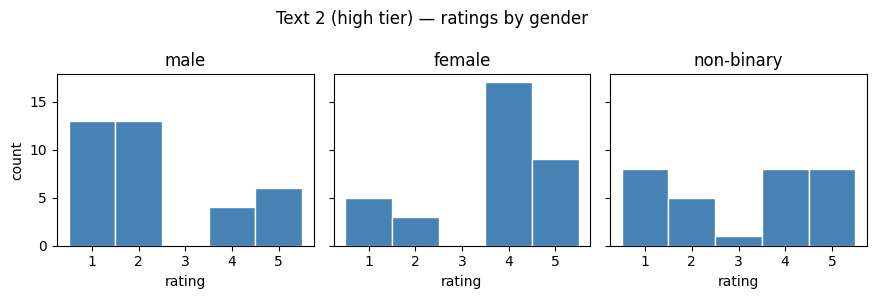

In [8]:
high_text_id = next(tid for tid, cfg in bias_configs.items() if cfg["tier"] == "high")
text_data = dataset[dataset["text_id"] == high_text_id]
scale = pool.scale
bins = range(1, scale + 2)

dim = "gender"
values = pool.active_dims[dim]

fig, axes = plt.subplots(1, len(values), figsize=(3 * len(values), 3), sharey=True)
fig.suptitle(f"Text {high_text_id} (high tier) — ratings by {dim}")

for ax, value in zip(axes, values):
    subset = text_data[text_data[dim] == value]["rating"]
    ax.hist(subset, bins=bins, align="left", color="steelblue", edgecolor="white")
    ax.set_title(value)
    ax.set_xlabel("rating")
    ax.set_xticks(range(1, scale + 1))

axes[0].set_ylabel("count")
plt.tight_layout()
plt.show()